# Benchmarking

In this section, we benchmark `GaugeFixer`'s computational performance for gauge-fixing computation in comparison with direct multiplication with the dense projection matrix.


In [1]:
import tracemalloc
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
from matplotlib.ticker import LogLocator, NullFormatter
from gaugefixer import AllOrderModel, PairwiseModel

### Model configurations

For simplicity, we will evaluate the performance on all-order and pairwise interaction models defined over protein sequences of different lengths. 

In [2]:
results = []
n_points = 12
alphabet_name = "protein"
models = [AllOrderModel, PairwiseModel]
seq_lengths = [np.arange(2, 6), np.geomspace(3, 150, n_points).astype(int)]

### Evaluate running time and memory usage

In [3]:
for model, Ls in zip(models, seq_lengths):
    for L in Ls:
        m = model(alphabet_name=alphabet_name, L=L)
        m.set_random_params()
        
        for use_dense_matrix in [False, True]:
            if use_dense_matrix and m.n_features > 10000:
                continue

            for i in range(11):
                tracemalloc.start()
                current1, peak1 = tracemalloc.get_traced_memory()
                t0 = time()
                theta_fixed = m.get_fixed_params(
                    gauge="zero-sum", use_dense_matrix=use_dense_matrix
                )
                t1 = time() - t0
                current2, peak2 = tracemalloc.get_traced_memory()
                tracemalloc.stop()

                # Skip the first run (warm-up)
                if i == 0:
                    continue

                results.append(
                    {
                        "model": model.__name__,
                        "n_features": m.n_features,
                        "alphabet_name": alphabet_name,
                        "time": t1,
                        "current_memory": (current2 - current1) / 1e6,
                        "peak_memory": (peak2 - peak1) / 1e6,
                        "dense_matrix": use_dense_matrix,
                    }
                )
results = pd.DataFrame(results)
results

,model,n_features,alphabet_name,time,current_memory,peak_memory,dense_matrix
0,AllOrderModel,441,protein,0.001605,0.010924,0.048751,False
1,AllOrderModel,441,protein,0.001165,0.009152,0.047243,False
2,AllOrderModel,441,protein,0.001037,0.009824,0.047979,False
3,AllOrderModel,441,protein,0.001023,0.009280,0.047371,False
4,AllOrderModel,441,protein,0.001694,0.009121,0.047276,False
...,...,...,...,...,...,...,...
205,PairwiseModel,4473001,protein,5.179069,71.571140,295.822343,False
206,PairwiseModel,4473001,protein,4.999057,71.570496,295.821699,False
207,PairwiseModel,4473001,protein,5.332721,71.571140,295.822343,False
208,PairwiseModel,4473001,protein,4.825775,71.570496,295.821699,False


### Visualize computational performance

In [4]:
colors = ["C0", "C0", "C1", "C1"]
models = ["AllOrderModel", "PairwiseModel"]
model_labels = ["all-order", "pairwise"]
model_dict = dict(zip(models, model_labels))

dense = [True, False]
dense_labels = ["standard", "GaugeFixer"]
dense_dict = dict(zip(dense, dense_labels))

labels = [
    f"{model} ({dense})" for model, dense in product(model_labels, dense_labels)
]
palette = dict(zip(labels, colors))
labels_dict = dict(zip(models, labels))
results["label"] = [
    f"{model_dict[m]} ({dense_dict[d]})"
    for m, d in zip(results["model"], results["dense_matrix"])
]
results

,model,n_features,alphabet_name,time,current_memory,peak_memory,dense_matrix,label
0,AllOrderModel,441,protein,0.001605,0.010924,0.048751,False,all-order (GaugeFixer)
1,AllOrderModel,441,protein,0.001165,0.009152,0.047243,False,all-order (GaugeFixer)
2,AllOrderModel,441,protein,0.001037,0.009824,0.047979,False,all-order (GaugeFixer)
3,AllOrderModel,441,protein,0.001023,0.009280,0.047371,False,all-order (GaugeFixer)
4,AllOrderModel,441,protein,0.001694,0.009121,0.047276,False,all-order (GaugeFixer)
...,...,...,...,...,...,...,...,...
205,PairwiseModel,4473001,protein,5.179069,71.571140,295.822343,False,pairwise (GaugeFixer)
206,PairwiseModel,4473001,protein,4.999057,71.570496,295.821699,False,pairwise (GaugeFixer)
207,PairwiseModel,4473001,protein,5.332721,71.571140,295.822343,False,pairwise (GaugeFixer)
208,PairwiseModel,4473001,protein,4.825775,71.570496,295.821699,False,pairwise (GaugeFixer)


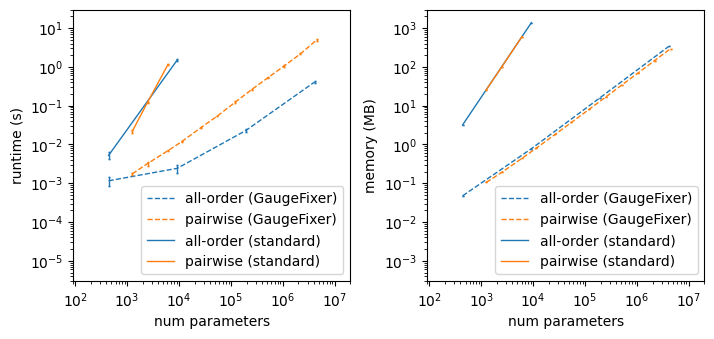

In [5]:
variables = {
    "time": "runtime (s)",
    "peak_memory": "memory (MB)",
}

lw = 1
kwargs = {
    "palette": palette,
    "errorbar": "sd",
    "err_style": "bars",
    "err_kws": {"capsize": lw, "elinewidth": lw, "capthick": lw},
    "lw": lw
}

fig, subplots = plt.subplots(
    1,
    2,
    figsize=(7, 3.25),
    sharex=True,
    sharey=False,
)

for i, (axes, (y, ylabel)) in enumerate(zip(subplots, variables.items())):
    for (dense, data), linestyle in zip(results.groupby('dense_matrix'), ['--', 'solid']):
        sns.lineplot(
            x="n_features",
            y=y,
            hue="label",
            data=data,
            ax=axes,
            linestyle=linestyle,
            **kwargs,
        )

    if i == 0:
        yticks=(1E-5,1E-4,1E-3,1E-2,1E-1,1E0,1E1)
        ylim=(3E-6, 3E1)
    else:
        yticks=(1E-3,1E-2,1E-1,1E0,1E1,1E2,1E3)
        ylim=(3E-4, 3E3)
    
    axes.set(
        xlabel="num parameters",
        ylabel=ylabel,
        xscale="log",
        yscale="log",
        xlim=(90, 2e7),
        ylim=ylim,
        xticks=(1E2,1E3,1E4,1E5,1E6,1E7),
        yticks=yticks,
        ymargin=0.2,
    )

    # Set log-scale minor tickmarks
    axes.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    axes.xaxis.set_minor_formatter(NullFormatter())
    axes.legend_.set_visible(False)
    axes.legend(loc=4)

fig.tight_layout(pad=0.2, w_pad=1)